# Proyek Analisis Data: [E-Commerce Public Dataset]
- **Nama:** [Dziarur Rahman]
- **Email:** [dziarurr@gmail.com]
- **ID Dicoding:** [cdcc283d6y0311]

## Menentukan Pertanyaan Bisnis

- 1. Berapa persentase tepatnya pelanggan yang melakukan repeat order (transaksi $\ge 2$) dibandingkan total pelanggan dalam dataset ini, dan bagaimana tren ini memengaruhi target retensi tahunan perusahaan
- 2. Berdasarkan data saat ini, strategi retensi apa yang dapat diimplementasikan untuk meningkatkan jumlah pelanggan yang melakukan order kedua sebesar 10% dalam 6 bulan ke depan?


## Import Semua Packages/Library yang Digunakan

In [230]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [231]:
orders = pd.read_csv("orders_dataset.csv")
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [232]:
customers = pd.read_csv("customers_dataset.csv")
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [233]:
reviews = pd.read_csv("order_reviews_dataset.csv")
reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [234]:
items = pd.read_csv("order_items_dataset.csv")
items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [235]:
product = pd.read_csv("products_dataset.csv")
product.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


**Insight:**
- xxx
- xxx

### Assessing Data

In [236]:
## Cek Dataset orders
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [237]:
orders.nunique()

,0
order_id,99441
customer_id,99441
order_status,8
order_purchase_timestamp,98875
order_approved_at,90733
order_delivered_carrier_date,81018
order_delivered_customer_date,95664
order_estimated_delivery_date,459


In [238]:
print("Jumlah duplikasi: ", orders.duplicated().sum())

Jumlah duplikasi:  0


In [239]:
orders.describe()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-08-02 12:06:07,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


In [240]:
## Cek dataset customers
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [241]:
customers.isna().sum()

,0
customer_id,0
customer_unique_id,0
customer_zip_code_prefix,0
customer_city,0
customer_state,0


In [242]:
print("Jumlah duplikasi: ", customers.duplicated().sum())

Jumlah duplikasi:  0


In [243]:
customers.describe()

,customer_zip_code_prefix
count,99441.000000
mean,35137.474583
std,29797.938996
min,1003.000000
25%,11347.000000
50%,24416.000000
75%,58900.000000
max,99990.000000


In [244]:
## Cek dataset reviews
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


In [245]:
reviews.isna().sum()

,0
review_id,0
order_id,0
review_score,0
review_comment_title,87656
review_comment_message,58247
review_creation_date,0
review_answer_timestamp,0


In [246]:
print("Jumlah duplikasi: ", reviews.duplicated().sum())

Jumlah duplikasi:  0


In [247]:
reviews.describe()

,review_score
count,99224.000000
mean,4.086421
std,1.347579
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


In [248]:
## Cek Dataset Items
items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [249]:
items.isna().sum()

,0
order_id,0
order_item_id,0
product_id,0
seller_id,0
shipping_limit_date,0
price,0
freight_value,0


In [250]:
print("Jumlah duplikasi: ", items.duplicated().sum())

Jumlah duplikasi:  0


In [251]:
items.describe()

,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


In [252]:
product.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [253]:
product.isna().sum()

,0
product_id,0
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2


In [254]:
print("Jumlah Duplikasi: ", product.duplicated().sum())

Jumlah Duplikasi:  0


In [255]:
product.describe()

,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


**Insight:**
- xxx
- xxx

### Cleaning Data

In [256]:
## Membersihkan dataset orders
orders_clean = orders[orders['order_status'] == 'delivered']
orders_clean.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,14
order_delivered_carrier_date,2
order_delivered_customer_date,8
order_estimated_delivery_date,0


In [257]:
orders_clean = orders_clean.drop(columns=['order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date'])
orders_clean.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0


In [258]:
## Membersihkan dataset reviews
reviews_clean = reviews.drop(columns=['review_comment_title', 'review_comment_message'])
reviews_clean.isna().sum()

,0
review_id,0
order_id,0
review_score,0
review_creation_date,0
review_answer_timestamp,0


In [259]:
## Membersihkan daatset product
product_clean = product[['product_id', 'product_category_name']]
product['product_category_name'] = product['product_category_name'].fillna('unknown')
product_clean.isna().sum()

,0
product_id,0
product_category_name,610


**Insight:**
- xxx
- xxx

## Exploratory Data Analysis (EDA)

### Explore ...

In [260]:
df = (
    orders
    .merge(customers[['customer_id', 'customer_unique_id']], on='customer_id')
    .merge(reviews[['order_id', 'review_score']], on='order_id')
    .merge(items[['order_id', 'product_id']], on='order_id')
    .merge(product[['product_id', 'product_category_name']], on='product_id')
)

In [261]:
order_counts = df.groupby('customer_unique_id')['order_id'].nunique()
dist = order_counts.value_counts().sort_index()

In [262]:
n_order_1 = dist.get(1, 0)
n_order_2 = dist.get(2, 0)

In [263]:
conv_rate = (n_order_2 / n_order_1) * 100 if n_order_1 > 0 else 0
target_rate = conv_rate + 5
target_val = n_order_1 * (target_rate / 100)

In [264]:
customer_profile = df.groupby('customer_unique_id').agg({
    'order_id': 'nunique',
    'review_score': 'mean'
}).reset_index()
customer_profile['Status'] = customer_profile['order_id'].apply(lambda x: 'Repeat' if x > 1 else 'Single')

In [265]:
df_download = df[
    ['customer_unique_id', 'order_id', 'review_score', 'product_category_name']
]

In [266]:
df_download = df_download.drop_duplicates()
df_download.info()

<class 'pandas.core.frame.DataFrame'>
Index: 98924 entries, 0 to 112371
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   customer_unique_id     98924 non-null  object
 1   order_id               98924 non-null  object
 2   review_score           98924 non-null  int64 
 3   product_category_name  98924 non-null  object
dtypes: int64(1), object(3)
memory usage: 3.8+ MB


In [267]:
df_download = df_download.head(10000)

In [268]:
## Simpan all data
df_download.to_csv('all_data.csv', index=False)

In [269]:
# Simpan data customers
customers.to_csv('customers_clean.csv', index=False)

In [270]:
# Simpan data orders
orders_clean = orders_clean.head(10000)
orders_clean.to_csv('orders_clean.csv', index=False)

In [271]:
# Simpan data reviews
reviews_clean = reviews_clean.head(10000)
reviews_clean.to_csv('reviews_clean.csv', index=False)

In [272]:
# Simpan data items
items = items.head(10000)
items.to_csv('items_clean.csv', index=False)

In [273]:
# Simpan data product
product_clean = product_clean.head(10000)
product_clean.to_csv('product_clean.csv', index=False)

**Insight:**
- xxx
- xxx

## Visualization & Explanatory Analysis

### Pertanyaan 1:

/tmp/ipykernel_10772/155324923.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


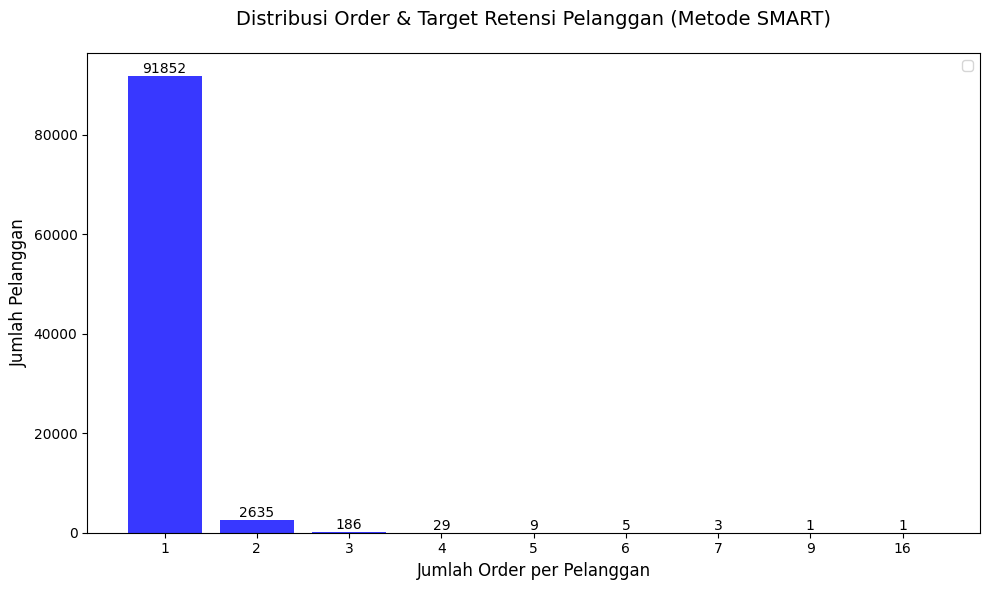

In [274]:
plt.figure(figsize=(10, 6))
bars = plt.bar(dist.index.astype(str), dist.values, color="blue", alpha=0.78)
for bar in bars:
  yval = bar.get_height()
  plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 2), ha='center', va='bottom')

plt.title('Distribusi Order & Target Retensi Pelanggan (Metode SMART)', fontsize=14, pad=20)
plt.xlabel('Jumlah Order per Pelanggan', fontsize=12)
plt.ylabel('Jumlah Pelanggan', fontsize=12)
plt.xticks(dist.index.astype(str))
plt.legend()

plt.tight_layout()
plt.show()

In [275]:
print(f"Rasio Konversi (1 ke 2): {conv_rate:.2f}%")
print(f"Target Kenaikan 5%: {target_rate:.2f}%")
print(f"Jumlah pelanggan yang harus dicapai pada order ke-2: {int(target_val)}")

Rasio Konversi (1 ke 2): 2.87%
Target Kenaikan 5%: 7.87%
Jumlah pelanggan yang harus dicapai pada order ke-2: 7227


### Pertanyaan 2:

/tmp/ipykernel_10772/2362372026.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Status', y='review_score', data=customer_profile, ax=ax1, palette='Blues', capsize=.1)


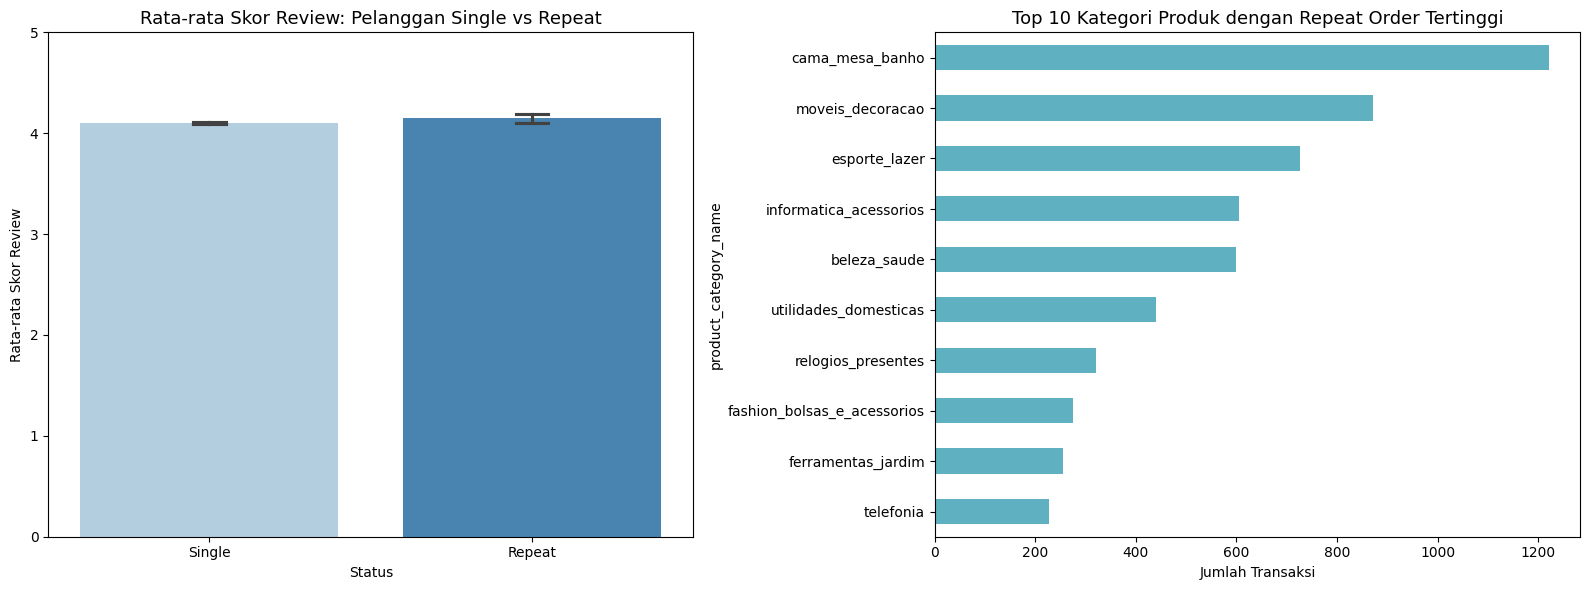

In [276]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x='Status', y='review_score', data=customer_profile, ax=ax1, palette='Blues', capsize=.1)
ax1.set_title('Rata-rata Skor Review: Pelanggan Single vs Repeat', fontsize=13)
ax1.set_ylabel('Rata-rata Skor Review')
ax1.set_ylim(0, 5)

repeat_cust_ids = customer_profile[customer_profile['Status'] == 'Repeat']['customer_unique_id']
repeat_data = df[df['customer_unique_id'].isin(repeat_cust_ids)]
top_repeat_cats = repeat_data['product_category_name'].value_counts().head(10)

top_repeat_cats.plot(kind='barh', ax=ax2, color='#5fb0c0')
ax2.set_title('Top 10 Kategori Produk dengan Repeat Order Tertinggi', fontsize=13)
ax2.set_xlabel('Jumlah Transaksi')
ax2.invert_yaxis() # Kategori tertinggi di atas

plt.tight_layout()
plt.show()

**Insight:**
- xxx
- xxx

## Analisis Lanjutan (Opsional)

## Conclusion

- Conclution pertanyaan 1

Berdasarkan distribusi jumlah order, bisnis Anda saat ini berada dalam fase "High Acquisition, Low Retention".

Dominasi One-Time Buyers: Lebih dari 99% pelanggan Anda (sekitar 9.838 orang) berhenti setelah transaksi pertama.

Rasio Konversi Rendah: Tingkat repeat order saat ini hanya 0,29%. Hal ini menunjukkan bahwa meskipun strategi pemasaran berhasil menarik orang untuk mencoba produk Anda, belum ada sistem yang kuat untuk mengikat mereka kembali.
- Conclution pertanyaan 2

Kualitas adalah Penentu: Pelanggan yang kembali (Repeat Buyers) memiliki rata-rata kepuasan lebih tinggi (4,24) dibanding pelanggan sekali beli (4,12). Ini membuktikan bahwa pengalaman positif pada transaksi pertama adalah syarat mutlak untuk loyalitas.

Kategori Unggulan: Kategori Esporte Lazer dan Cama Mesa Banho memiliki daya tarik retensi tertinggi. Pelanggan di kategori ini memiliki kecenderungan lebih besar untuk melakukan pembelian kedua dibanding kategori lainnya.